In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from data import CaseHFL, CaseHFL_Heterogeneous
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from typing import List

In [15]:
class MAMLRegression(nn.Module):
    def __init__(self, input_size):
        super(MAMLRegression, self).__init__()

        self.weight = nn.Parameter(torch.Tensor(1, input_size))
        self.bias = nn.Parameter(torch.Tensor(1))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.zeros_(self.bias)
        
    def forward(self, x, weights=None):
        # bias + x times weights
        if weights is None:
            return torch.addmm(self.bias, x, self.weight.t())
        
        return torch.addmm(weights['bias'], x, weights['weight'].t())

def maml_update(model, x_train, y_train, x_validation, y_validation, inner_lr, meta_optimizer):
    meta_optimizer.zero_grad()
    meta_loss = 0.0
    
    for i in range(len(x_train)):
        x_support = torch.tensor(x_train[i].T, dtype=torch.float32)
        y_support = torch.tensor(y_train[i], dtype=torch.float32).view(-1, 1)
        x_query = torch.tensor(x_validation[i].T, dtype=torch.float32)
        y_query = torch.tensor(y_validation[i], dtype=torch.float32).view(-1, 1)

        pred_s = model(x_support)
        inner_loss = nn.MSELoss()(pred_s, y_support)
        
        grads = torch.autograd.grad(inner_loss, model.parameters(), create_graph=True)
        
        hypothetical_weights = {}
        for (name, param), grad in zip(model.named_parameters(), grads):
            hypothetical_weights[name] = param - inner_lr * grad
            
        pred_query = model(x_query, weights=hypothetical_weights)
        task_meta_loss = nn.MSELoss()(pred_query, y_query)
        meta_loss += task_meta_loss

    average_meta_loss = meta_loss / len(x_train)
    average_meta_loss.backward()
    meta_optimizer.step()
    
    return average_meta_loss.item()

In [16]:
rng = np.random.default_rng(42)
case = CaseHFL_Heterogeneous(
    rng = rng,
    n = 1000,
    events = 200,
    output_arity = 50,
    sensors = 50,
    noise_std = 0.01,
    heterogeneity_std=1.0
)

In [17]:
X_train, Y_train = case.generate_data()
X_validation, Y_validation = case.generate_data()
X_test, Y_test = case.generate_data()
scaler_x = StandardScaler()
scaler_y = StandardScaler()


X_train = [scaler_x.fit_transform(x.T).T for x in X_train]
X_validation = [scaler_x.fit_transform(x.T).T for x in X_validation]
X_test = [scaler_x.fit_transform(x.T).T for x in X_test]
Y_train = [scaler_y.fit_transform(y.reshape(-1, 1)).flatten() for y in Y_train]
Y_validation = [scaler_y.fit_transform(y.reshape(-1, 1)).flatten() for y in Y_validation]
Y_test = [scaler_y.fit_transform(y.reshape(-1, 1)).flatten() for y in Y_test]

In [18]:
input_dim = X_train[0].shape[0]
meta_model = MAMLRegression(input_dim)
meta_opt = optim.Adam(meta_model.parameters(), lr=0.001)

for epoch in range(100):
   loss = maml_update(meta_model, X_train, Y_train, X_validation, Y_validation, 0.01, meta_opt)

In [19]:
def evaluate_maml(model, x_support, y_support, x_query, y_query, inner_lr, steps=1):
    model.eval()
    
    x_support = torch.tensor(x_support.T, dtype=torch.float32)
    y_support = torch.tensor(y_support, dtype=torch.float32).view(-1, 1)
    x_query = torch.tensor(x_query.T, dtype=torch.float32)
    y_query = torch.tensor(y_query, dtype=torch.float32).view(-1, 1)

    new_learned_weights = {name: param for name, param in model.named_parameters()}
    
    for _ in range(steps):
        pred_s = model(x_support, weights=new_learned_weights)
        loss_s = nn.MSELoss()(pred_s, y_support)
        
        grads = torch.autograd.grad(loss_s, new_learned_weights.values())
        
        new_learned_weights = {
            name: param - inner_lr * grad 
            for (name, param), grad in zip(new_learned_weights.items(), grads)
        }

    with torch.no_grad():
        pred_q = model(x_query, weights=new_learned_weights)
        query_loss = nn.MSELoss()(pred_q, y_query)
    
    return query_loss.item(), pred_q.numpy()

In [20]:
test_losses = []
all_predictions = []

inner_lr = 0.01 
adaptation_steps = 3 

for i in range(len(X_test)):
    sample_count = X_test[i].shape[1]
    
    split_idx = int(sample_count * 0.2) 
    
    x_support = X_test[i][:, :split_idx]
    y_support = Y_test[i][:split_idx]
    
    x_query = X_test[i][:, split_idx:]
    y_query = Y_test[i][split_idx:]
    
    mse, preds = evaluate_maml(
        meta_model, 
        x_support, 
        y_support, 
        x_query, 
        y_query, 
        inner_lr, 
        steps=adaptation_steps
    )
    
    test_losses.append(mse)
    all_predictions.append(preds)

average_mse = np.mean(test_losses)
print(f"Average Test MSE across {len(X_test)} tasks: {average_mse:.4f}")

Average Test MSE across 50 tasks: 0.8656


In [21]:
scaler_x, scaler_y = StandardScaler(), StandardScaler()
def scale_data(X, Y):
    Xs = [scaler_x.fit_transform(x.T).T for x in X]
    Ys = [scaler_y.fit_transform(y.reshape(-1, 1)).flatten() for y in Y]
    return Xs, Ys

In [22]:
def train_maml_model(model, X_train, Y_train, X_val, Y_val, epochs=100, lr_inner=0.01):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(epochs):
        loss = maml_update(model, X_train, Y_train, X_val, Y_val, lr_inner, optimizer)
        
    return model

In [23]:
def evaluate_maml_task(case_class, case_params):
    rng = np.random.default_rng(case_params.get('seed', 42))
    
    case = case_class(
        rng=rng,
        **{k: v for k, v in case_params.items() if k != 'seed'}
    )

    X_train, Y_train = case.generate_data()
    X_validation, Y_validation = case.generate_data()
    X_test, Y_te_raw = case.generate_data()

    X_train, Y_train = scale_data(X_train, Y_train)
    X_val, Y_val = scale_data(X_validation, Y_validation)
    X_test, Y_test = scale_data(X_test, Y_te_raw)

    input_dim = X_train[0].shape[0]
    meta_model = MAMLRegression(input_dim)
    
    meta_model = train_maml_model(meta_model, X_train, Y_train, X_val, Y_val, epochs=100)

    test_losses = []
    for i in range(len(X_test)):
        sample_count = X_test[i].shape[1]
        split_idx = int(sample_count * 0.2) # 20% Support
        
        mse, _ = evaluate_maml(
            meta_model, 
            X_test[i][:, :split_idx], Y_test[i][:split_idx], 
            X_test[i][:, split_idx:], Y_test[i][split_idx:], 
            inner_lr=0.01, steps=3
        )
        test_losses.append(mse)

    return np.mean(test_losses)

In [24]:
def sweep_parameter(eval_func, case_class, base_params, sweep_key, sweep_values):
    results = []
    for value in sweep_values:
        current_params = base_params.copy()
        current_params[sweep_key] = value
        
        mse = eval_func(case_class, current_params)
        results.append(mse)
        
    return results

In [25]:
def plot_results(x_values, y_values, xlabel, title, filename):
    plt.figure(figsize=(10, 6))
    plt.plot(x_values, y_values, marker='o', linestyle='-', color='b', label='FedAVG MSE')
    
    plt.title(title)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.legend()
    
    plt.savefig(f'./figures/{filename}')
    plt.show()

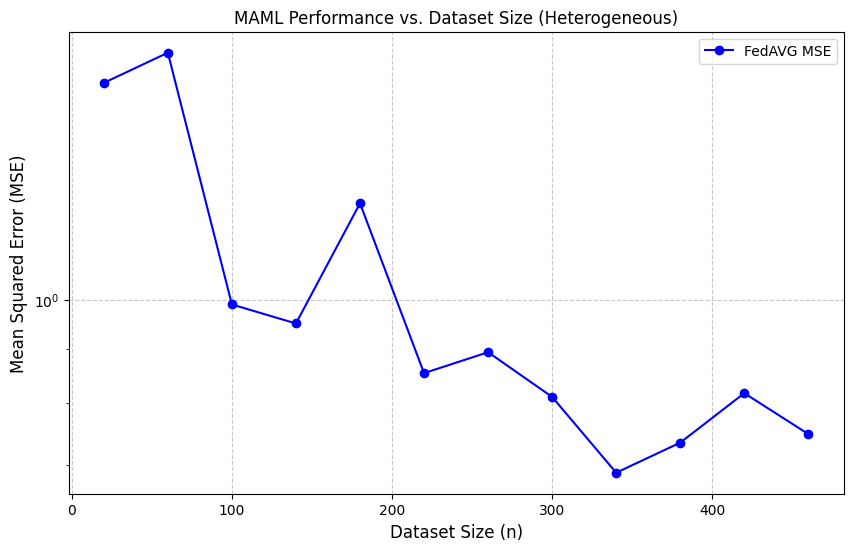

In [26]:
base_config = {
    'n': 500, 
    'events': 100,
    'output_arity': 50,
    'sensors': 10,
    'noise_std': 0.01,
    'seed': 42
}

n_values = range(20, 500, 40)

maml_n_results = sweep_parameter(
    eval_func=evaluate_maml_task,
    case_class=CaseHFL_Heterogeneous,
    base_params=base_config,
    sweep_key='n', 
    sweep_values=n_values
)

plot_results(
    x_values=n_values,            
    y_values=maml_n_results,
    xlabel='Dataset Size (n)',      
    title='MAML Performance vs. Dataset Size (Heterogeneous)', 
    filename='MAML_datasetsize_heterogeneous'  
)

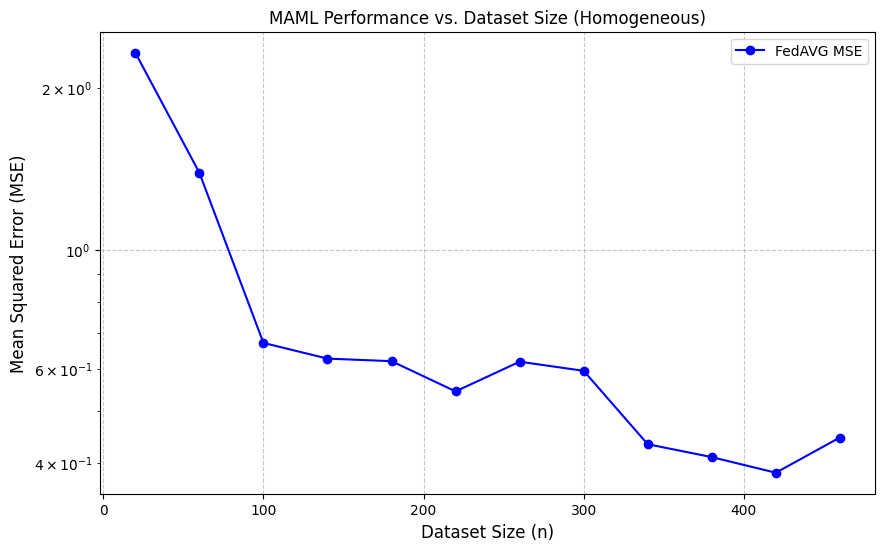

In [27]:
maml_n_results = sweep_parameter(
    eval_func=evaluate_maml_task,
    case_class=CaseHFL,
    base_params=base_config,
    sweep_key='n', 
    sweep_values=n_values
)

plot_results(
    x_values=n_values,            
    y_values=maml_n_results,
    xlabel='Dataset Size (n)',      
    title='MAML Performance vs. Dataset Size (Homogeneous)', 
    filename='MAML_datasetsize_homogeneous'  
)

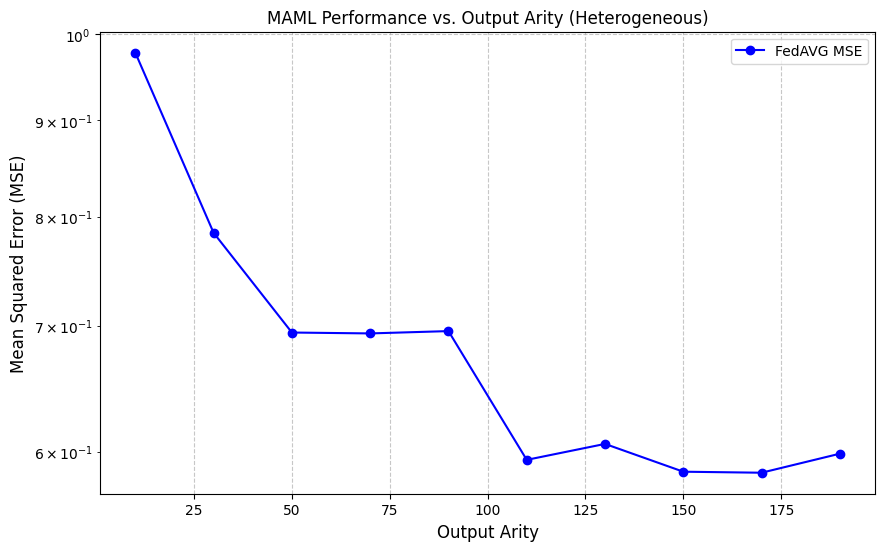

In [31]:
base_config = {
    'n': 1000,
    'events': 200,
    'output_arity': 50,
    'sensors': 10,
    'noise_std': 0.01,
    'seed': 42
}

arity_values = range(10, 200, 20)

maml_arity_results = sweep_parameter(
    eval_func=evaluate_maml_task,
    case_class=CaseHFL_Heterogeneous,
    base_params=base_config,
    sweep_key='output_arity',
    sweep_values=arity_values
)

plot_results(
    x_values=arity_values,
    y_values=maml_arity_results,
    xlabel='Output Arity',
    title='MAML Performance vs. Output Arity (Heterogeneous)',
    filename='MAML_arity_heterogeneous.png'
)

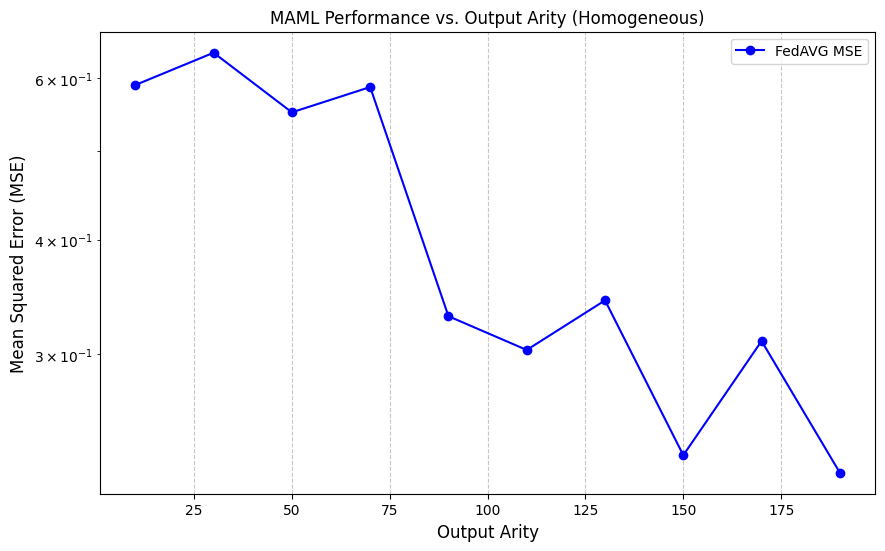

In [32]:
maml_arity_results = sweep_parameter(
    eval_func=evaluate_maml_task,
    case_class=CaseHFL,
    base_params=base_config,
    sweep_key='output_arity',
    sweep_values=arity_values
)

plot_results(
    x_values=arity_values,
    y_values=maml_arity_results,
    xlabel='Output Arity',
    title='MAML Performance vs. Output Arity (Homogeneous)',
    filename='MAML_arity_homoogeneous.png'
)

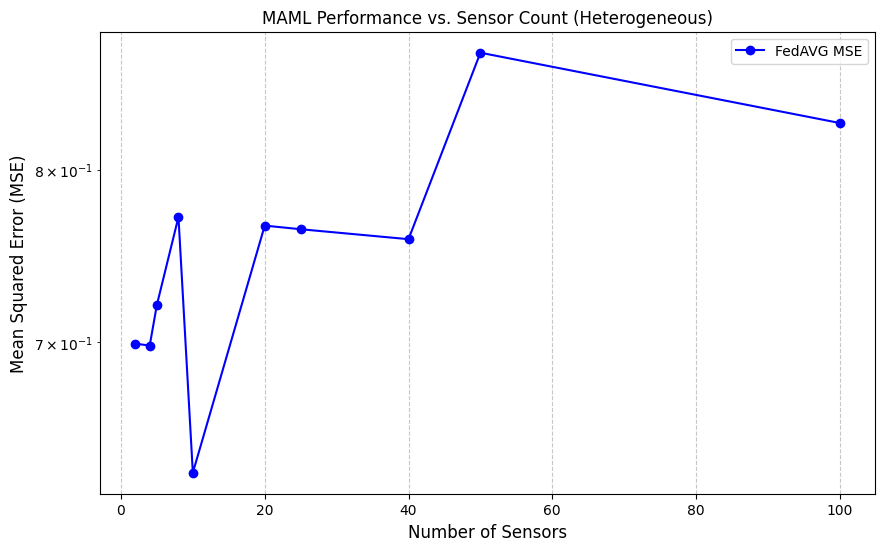

In [46]:
base_config = {
    'n': 1000,
    'events': 200,
    'output_arity': 50,
    'sensors': 10, 
    'noise_std': 0.01,
    'seed': 42
}

sensor_values = [2, 4, 5, 8, 10, 20, 25, 40, 50, 100]

maml_sensor_results = sweep_parameter(
    eval_func=evaluate_maml_task,
    case_class=CaseHFL_Heterogeneous,
    base_params=base_config,
    sweep_key='sensors',            
    sweep_values=sensor_values
)

plot_results(
    x_values=list(sensor_values),   
    y_values=maml_sensor_results,
    xlabel='Number of Sensors',    
    title='MAML Performance vs. Sensor Count (Heterogeneous)', 
    filename='MAML_sensors_heterogeneous.png'
)

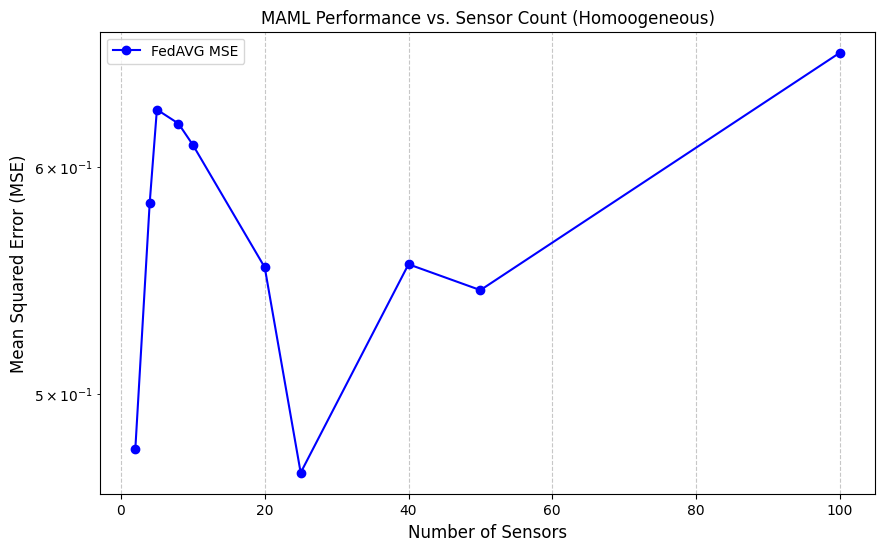

In [47]:
maml_sensor_results = sweep_parameter(
    eval_func=evaluate_maml_task,
    case_class=CaseHFL,
    base_params=base_config,
    sweep_key='sensors',            
    sweep_values=sensor_values
)

plot_results(
    x_values=list(sensor_values),   
    y_values=maml_sensor_results,
    xlabel='Number of Sensors',    
    title='MAML Performance vs. Sensor Count (Homoogeneous)', 
    filename='MAML_sensors_homoogeneous.png'
)